# Taylor 1.50: the oscillating skateboard, beyond small angles

**Starter notebook for HW01, PHY 317 (Smith, Fall 2026).** Runs as-is on posit.smith.edu; edit the cells marked *YOUR TURN*.

In Example 1.2 the skateboard in the half-pipe obeys

$$\ddot\phi = -\frac{g}{R}\sin\phi ,$$

and we turned it into a simple harmonic oscillator by writing $\sin\phi \approx \phi$. Problem 1.50 asks you to solve the *real* equation numerically and find out how large $\phi_0$ can be before the small-angle answer $\phi(t) = \phi_0\cos(\omega_0 t)$, $\omega_0 = \sqrt{g/R}$, stops being good.

**Before you run anything, write down a prediction** (in the markdown cell at the bottom): at what release angle do you expect the two curves to differ visibly after a few periods, and will the real pendulum run *fast* or *slow* relative to the small-angle one?

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

g = 9.8      # m/s^2
R = 5.0      # m, radius of the half-pipe (Taylor's example; try others)
omega0 = np.sqrt(g / R)
T0 = 2 * np.pi / omega0     # small-angle period
print(f"omega0 = {omega0:.3f} rad/s, small-angle period T0 = {T0:.3f} s")

omega0 = 1.400 rad/s, small-angle period T0 = 4.488 s


In [2]:
def rhs(t, state):
    """state = [phi, phidot]; returns [phidot, phiddot] for the FULL equation."""
    phi, phidot = state
    return [phidot, -(g / R) * np.sin(phi)]

def solve_full(phi0_deg, n_periods=4, released_from_rest=True):
    phi0 = np.radians(phi0_deg)
    t = np.linspace(0, n_periods * T0, 2000)
    sol = solve_ivp(rhs, (t[0], t[-1]), [phi0, 0.0], t_eval=t,
                    rtol=1e-10, atol=1e-12)
    return t, sol.y[0]

def small_angle(t, phi0_deg):
    return np.radians(phi0_deg) * np.cos(omega0 * t)

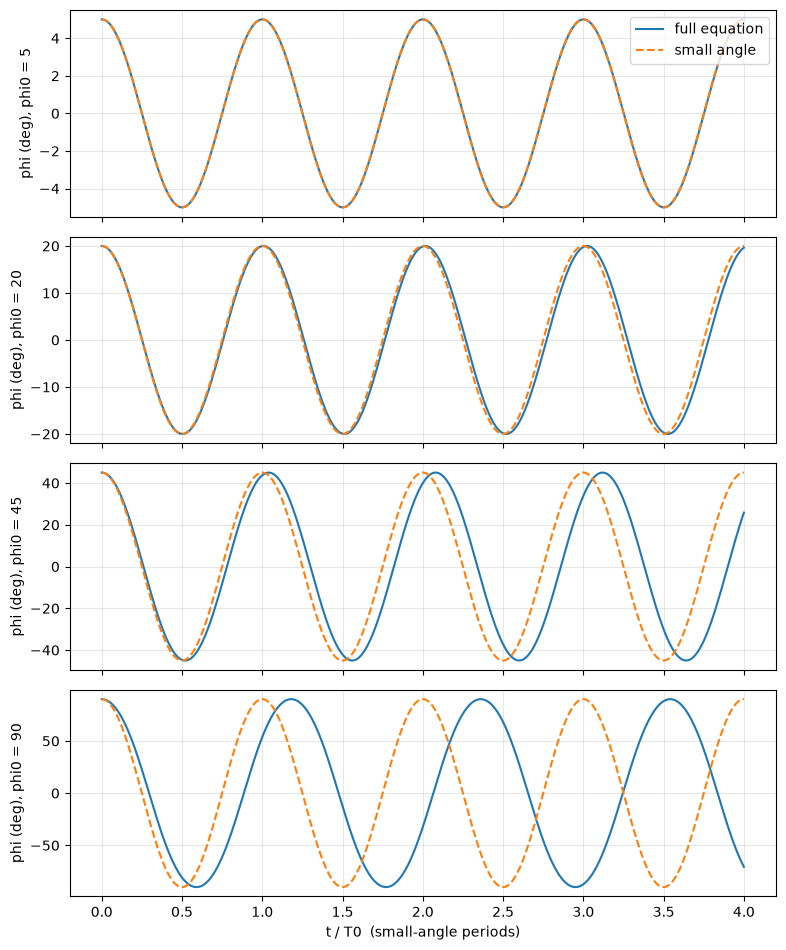

In [3]:
# YOUR TURN: change the release angles. Taylor suggests comparing several.
angles = [5, 20, 45, 90]

fig, axes = plt.subplots(len(angles), 1, figsize=(8, 2.4 * len(angles)), sharex=True)
for ax, a in zip(axes, angles):
    t, phi = solve_full(a)
    ax.plot(t / T0, np.degrees(phi), label="full equation")
    ax.plot(t / T0, np.degrees(small_angle(t, a)), "--", label="small angle")
    ax.set_ylabel(f"phi (deg), phi0 = {a}")
    ax.grid(alpha=0.3)
axes[0].legend(loc="upper right")
axes[-1].set_xlabel("t / T0  (small-angle periods)")
plt.tight_layout()

## Period vs amplitude

A cleaner way to see the breakdown: measure the *actual* period of the full solution as a function of $\phi_0$ and compare it with $T_0$. (Taylor 4.39, later in the course, derives this curve analytically; here we just measure it.)

phi0 =  10 deg: T/T0 = 1.0025
phi0 =  30 deg: T/T0 = 1.0145
phi0 =  45 deg: T/T0 = 1.0385
phi0 =  90 deg: T/T0 = 1.1766


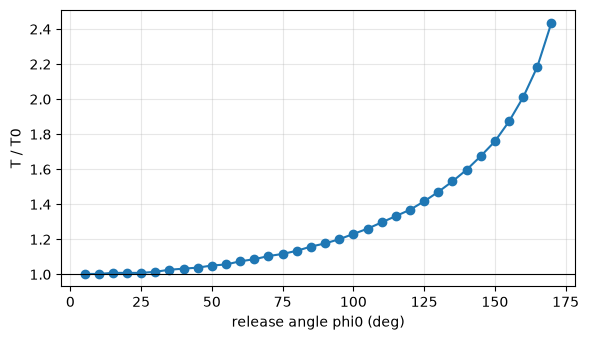

In [4]:
def measured_period(phi0_deg):
    """Time between the first two downward zero crossings of phi(t)."""
    t, phi = solve_full(phi0_deg, n_periods=12)   # long enough even near 180 deg
    crossings = t[:-1][(phi[:-1] > 0) & (phi[1:] <= 0)]
    return crossings[1] - crossings[0]

phi0s = np.arange(5, 171, 5)
ratios = [measured_period(a) / T0 for a in phi0s]

plt.figure(figsize=(6, 3.5))
plt.plot(phi0s, ratios, "o-")
plt.axhline(1, color="k", lw=0.8)
plt.xlabel("release angle phi0 (deg)")
plt.ylabel("T / T0")
plt.grid(alpha=0.3)
plt.tight_layout()
for a in (10, 30, 45, 90):
    print(f"phi0 = {a:3d} deg: T/T0 = {measured_period(a)/T0:.4f}")

## YOUR TURN: write-up

1. **Prediction (written before running):** ...
2. **What you found:** at what $\phi_0$ does the small-angle approximation fail by more than, say, 1% in the period? Does the real skateboard run fast or slow, and can you explain *why* from the sign of $\sin\phi - \phi$?
3. **Assessment:** one check that convinces you the numerical solution is right (a limit, a conserved quantity, a comparison with the small-angle formula where it should hold).
4. **What did not work** the first time, if anything.

Put your plots and these answers in your homework PDF.